<a href="https://colab.research.google.com/github/LuisPichal-52/2257-fundamentos-ia-explorando-algoritmos-y-enfoques-de-ml/blob/main/NoSupervisado.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Aplicando técnicas de aprendizaje no supervisado

#### ¿Cómo identificar patrones y agrupamientos naturales en un conjunto de datos?
Para la identificación de patrones y poderlos agrupar se usa el método K-means, con lo que se agrupa por cercanía geometrica y con el agrupamiento jerarquico se realiza la creación del dendrograma.  

#### ¿Cómo reducir la complejidad de los datos manteniendo la información más relevante?
En este nos apoyamos en el PCA para que las 4 variables de la flor iris se puedan comprimir y con ello solo usar dos dimensiones, con esto no se pierde información importante y lo podemos ver en un gráfico plano.


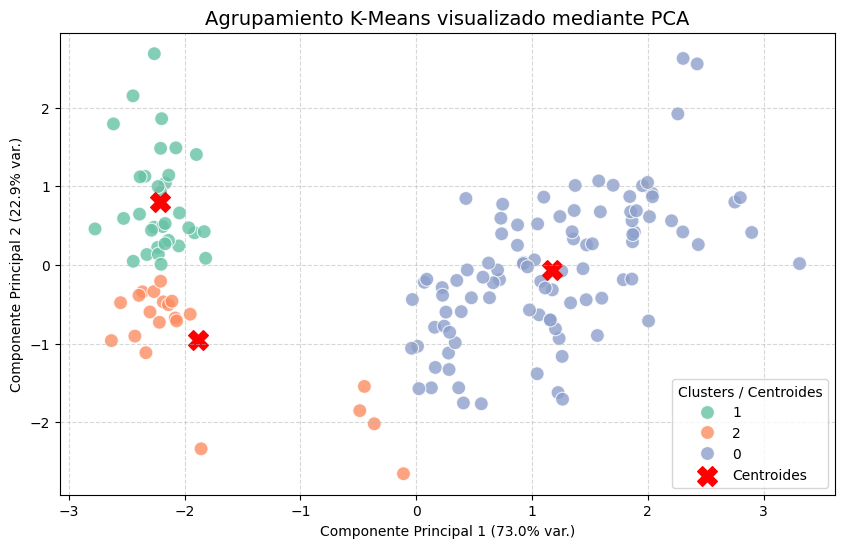

In [5]:
# Primero se importan las librerías a usar
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

# 1. Aquí se carga el dataset Iris
iris = load_iris()
X = iris.data
# Se guardan las especies reales
especies_reales = iris.target

# 2. ESCALAR LOS DATOS (Esto para el uso en K-Means y PCA)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 3. PCA: Reducir de 4 dimensiones a 2
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Crear un DataFrame con los componentes principales
df_pca = pd.DataFrame(data=X_pca, columns=['Componente Principal 1', 'Componente Principal 2'])

# 4. K-MEANS: Agrupar en 3 clusters (sabemos que hay 3 tipos de Iris)
kmeans = KMeans(n_clusters=3, random_state=42, n_init='auto')
df_pca['Cluster_KMeans'] = kmeans.fit_predict(X_scaled)

# Convertir a tipo string/categoría para evitar advertencias en el gráfico
df_pca['Cluster_KMeans'] = df_pca['Cluster_KMeans'].astype(str)

# 5. VISUALIZACIÓN
plt.figure(figsize=(10, 6))
sns.scatterplot(
    x='Componente Principal 1',
    y='Componente Principal 2',
    hue='Cluster_KMeans',
    data=df_pca,
    palette='Set2',
    s=100,
    alpha=0.8
)

# Dibujar los centroides de los clusters en el espacio PCA
centroides_scaled = kmeans.cluster_centers_
centroides_pca = pca.transform(centroides_scaled)
plt.scatter(centroides_pca[:, 0], centroides_pca[:, 1], c='red', marker='X', s=200, label='Centroides')

plt.title("Agrupamiento K-Means visualizado mediante PCA", fontsize=14)
plt.xlabel(f"Componente Principal 1 ({pca.explained_variance_ratio_[0]*100:.1f}% var.)")
plt.ylabel(f"Componente Principal 2 ({pca.explained_variance_ratio_[1]*100:.1f}% var.)")
plt.legend(title="Clusters / Centroides")
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

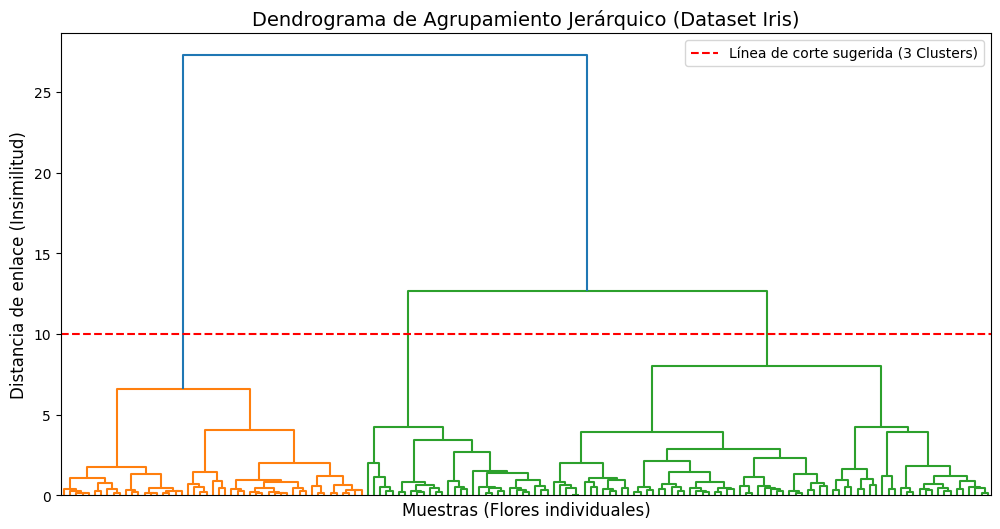

In [3]:
import scipy.cluster.hierarchy as sch
from sklearn.cluster import AgglomerativeClustering

# Usamos los mismos datos escalados del bloque anterior
plt.figure(figsize=(12, 6))

# 1. Crear el enlace jerárquico usando el método de Ward (minimiza la varianza interna)
enlace = sch.linkage(X_scaled, method='ward')

# 2. Graficar el Dendrograma
dendrograma = sch.dendrogram(enlace, no_labels=True) # Ocultamos etiquetas individuales para que no se sature

plt.title("Dendrograma de Agrupamiento Jerárquico (Dataset Iris)", fontsize=14)
plt.xlabel("Muestras (Flores individuales)", fontsize=12)
plt.ylabel("Distancia de enlace (Insimilitud)", fontsize=12)

# Línea sugerida de corte para obtener 3 clusters
plt.axhline(y=10, color='r', linestyle='--', label='Línea de corte sugerida (3 Clusters)')
plt.legend()
plt.show()